<a href="https://colab.research.google.com/github/Nandana-S30/Static-webpage/blob/main/SmartRecruit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- AI RECRUITMENT RANKING REPORT ---
Candidate_Name  Match_Score      Status
     Nandana S        48.94 Shortlisted
   Alice Smith        29.84    Reviewed
      John Doe         2.37    Reviewed


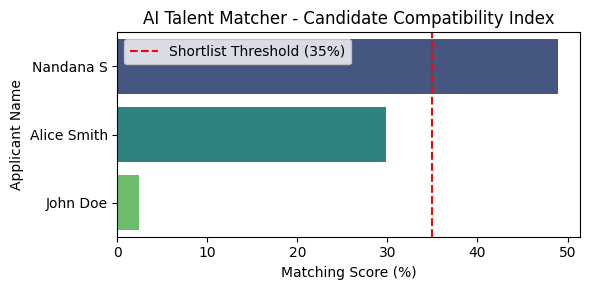

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Target Job Description
job_description = """
Seeking an Associate Data Scientist with strong technical documentation skills.
Must be proficient in Python programming, structured data preparation, and machine learning.
Experience with Exploratory Data Analysis (EDA), data cleaning, feature engineering, and model validation is required.
Familiarity with PostgreSQL, Django, and Git/GitHub version control is a plus.
"""

# 2. Candidate Resume Data
raw_candidates = {
    "Candidate_Name": ["Nandana S", "John Doe", "Alice Smith"],
    "Resume_Text": [
        "MCA graduate with practical experience in Python, data preparation, and machine learning. Conducted exploratory data analysis (EDA), data cleaning, and feature engineering to prepare datasets. Validated model performance using standard evaluation metrics. Built backend infrastructure using PostgreSQL and Django while maintaining detailed technical documentation. Proficient in Git and GitHub.",
        "Experienced Java Developer with 5 years in corporate IT systems. Skilled in Spring Boot, microservices architecture, Oracle SQL, and cloud deployments on AWS. Strong team player focused on backend system performance and enterprise software testing.",
        "Data Analyst with 2 years of experience. Expert in Excel formulas, Tableau dashboards, and SQL queries. Performed basic data cleaning and exploratory data analysis. Looking to transition into a junior machine learning role."
    ]
}

df = pd.DataFrame(raw_candidates)

# 3. NLP Feature Extraction (TF-IDF Vectorization)
vectorizer = TfidfVectorizer(stop_words='english')
all_texts = [job_description] + df['Resume_Text'].tolist()
tfidf_matrix = vectorizer.fit_transform(all_texts)

# 4. Compute Similarity Model Metrics
similarity_scores = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:]).flatten()
df['Match_Score'] = np.round(similarity_scores * 100, 2)
df['Status'] = df['Match_Score'].apply(lambda x: 'Shortlisted' if x >= 35 else 'Reviewed')
df_ranked = df.sort_values(by='Match_Score', ascending=False)

# 5. Display Final Structured Report
print("\n--- AI RECRUITMENT RANKING REPORT ---")
print(df_ranked[['Candidate_Name', 'Match_Score', 'Status']].to_string(index=False))

# 6. Generate and Display Performance Analytics Visual
plt.figure(figsize=(6, 3))
sns.barplot(x='Match_Score', y='Candidate_Name', data=df_ranked, palette='viridis')
plt.axvline(x=35, color='red', linestyle='--', label='Shortlist Threshold (35%)')
plt.title('AI Talent Matcher - Candidate Compatibility Index')
plt.xlabel('Matching Score (%)')
plt.ylabel('Applicant Name')
plt.legend()
plt.tight_layout()
plt.show()